# Incremental 4DVar on Lorenz-63 — analysis + free forecast

The operational fast path. Same problem as strong-4DVar but the
inner minimisation is split into Gauss-Newton outer iterations
(linearise around the current iterate) and CG inner iterations
(solve the linearised quadratic). At each outer iteration:

1. Linearise $M_t$, $H_t$ at the current outer iterate.
2. Form the Gauss-Newton Hessian
   $J''_\text{GN} = B^{-1} + \sum_t (H'_t M'_t)^\top R_t^{-1}
   (H'_t M'_t)$.
3. Solve $J''_\text{GN}\,\delta x^* = -\nabla J(x_b)$ with
   `lineax.CG`.
4. Update $x_b^{(k+1)} = x_b^{(k)} + \delta x^*$.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import (
    Lorenz63Forward,
    assemble_full_trajectory,
    assim_batch,
    generate_problem,
    run_method,
)

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = assim_batch(prob)
fwd = Lorenz63Forward(dt=prob.dt)
t_axis = jnp.arange(prob.T_total_plus_1) * prob.dt

## 2. Build Incremental-4DVar

In [3]:
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((3,), jnp.float32))
inc = vdx.IncrementalFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    config=vdx.IncrementalConfig(n_outer=4, n_inner=30),
)


def inc_run():
    return assemble_full_trajectory(inc(batch)[0], prob, fwd)


result = run_method("incremental_4dvar", inc_run, prob)
print(f"Incremental-4DVar rmse_assim    = {result.rmse_assim:.3f}")
print(f"Incremental-4DVar rmse_forecast = {result.rmse_forecast:.3f}")
print(f"Incremental-4DVar rmse_total    = {result.rmse_total:.3f}")
print(f"Incremental-4DVar runtime       = {result.runtime_ms:.1f} ms")

Incremental-4DVar rmse_assim    = 1.204
Incremental-4DVar rmse_forecast = 2.168
Incremental-4DVar rmse_total    = 2.129
Incremental-4DVar runtime       = 8820.7 ms


## 3. Trajectories

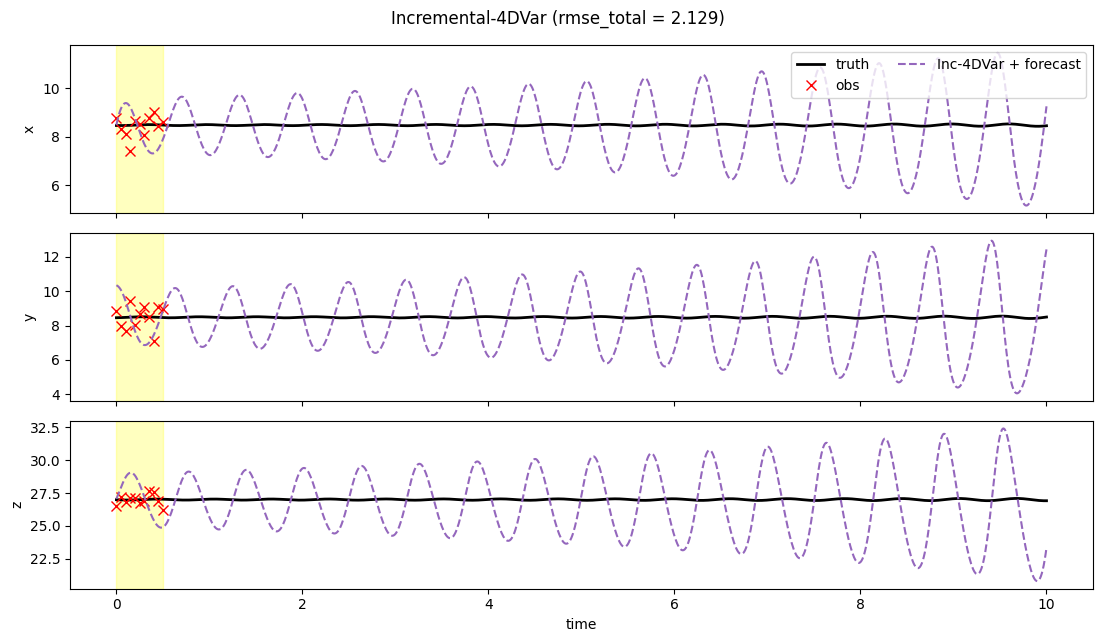

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
t_obs = t_axis[: prob.T_assim_plus_1][prob.mask[:, 0] > 0.5]
for i, ax in enumerate(axs):
    ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
    ax.plot(t_axis, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_v = prob.obs[prob.mask[:, i] > 0.5, i]
    if len(obs_v) > 0:
        ax.plot(t_obs, obs_v, "rx", ms=7, label="obs")
    ax.plot(t_axis, result.mean[:, i], "C4--", lw=1.5, label="Inc-4DVar + forecast")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right", ncol=2)
axs[-1].set_xlabel("time")
fig.suptitle(f"Incremental-4DVar (rmse_total = {result.rmse_total:.3f})")
fig.tight_layout()
plt.show()

## 4. RMSE(t)

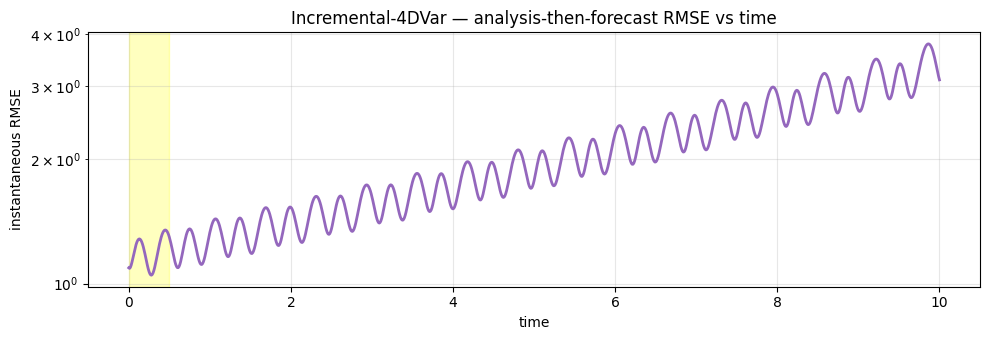

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
ax.plot(t_axis, result.rmse_trace, "C4-", lw=2, label="Inc-4DVar")
ax.set_xlabel("time")
ax.set_ylabel("instantaneous RMSE")
ax.set_yscale("log")
ax.set_title("Incremental-4DVar — analysis-then-forecast RMSE vs time")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 5. Discussion

Incremental-4DVar reaches similar forecast skill to strong-4DVar
at a similar per-evaluation cost on this 3-D problem. The
operational win shows up at larger state dimensions (see the L96
benchmarks), where the GN/CG split lets us avoid full-Newton on
the nonlinear cost and instead invert a CG-approximated Hessian
at each outer step.

At larger state dimensions and stiffer dynamics — e.g. the two-
level L96 — incremental-4DVar's GN linearisation can become
numerically singular; see notebook
[`12_lorenz96_2l_benchmark`](12_lorenz96_2l_benchmark.ipynb) for
the documented failure mode.